# Configuration

In [1]:
import os 
import warnings
warnings.filterwarnings('ignore')
if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

from datetime import datetime

In [2]:
import pandas as pd 
import numpy as np

In [3]:
from scipy.stats import norm, invgamma
# estimators
# from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS, WLS

from sklearn.linear_model import LogisticRegression

from scipy.integrate import quad 
from scipy.stats import ks_2samp
from scipy.optimize import fmin, minimize

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams['text.usetex'] = False

In [5]:
from core.variables import * 
from core.pricing_estimators import *
from core.dgp import *
from core.pricing_experiments import *
from core.visualization import *

# DGP

In [6]:
# parameters
train_size = 1000
dgp_params = {
    'cov_dim': 1,
    'util_map_lb': -1, 'util_map_ub': 1, 
    'price_map_lb': -3, 'price_map_ub': -1, 
    'char_mean': 1, 'char_std': 1
}

price_lb, price_ub, price_diff = 0, 10, 0.01

# initialize the data generating process
dgp = PersonalizedPricingDGP(**dgp_params)

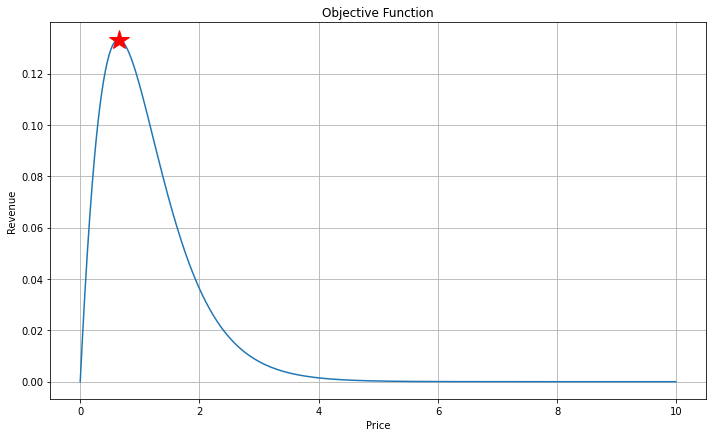

In [7]:
# visualize objective function
price_range = np.arange(price_lb, price_ub, price_diff)
cov = dgp.sample_individuals(sample_size=1)
obj_vals = np.array([obj_func(cov, price, dgp.true_util_params, add_const=False) for price in price_range])

opt_result = optimize_targeting(
    covariates=cov, params=dgp.true_util_params, add_const=False, 
    price_lb=price_lb, price_ub=price_ub
)
best_price = opt_result.x[0]
opt_revenue = -opt_result.fun

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))
ax.plot(price_range, obj_vals)
# add a point on the curve for the optimal price using star
ax.plot(best_price, opt_revenue, 'r*', markersize=20)
ax.set_xlabel('Price')
ax.set_ylabel('Revenue')
ax.set_title('Objective Function')
plt.grid()
plt.tight_layout()
plt.show()

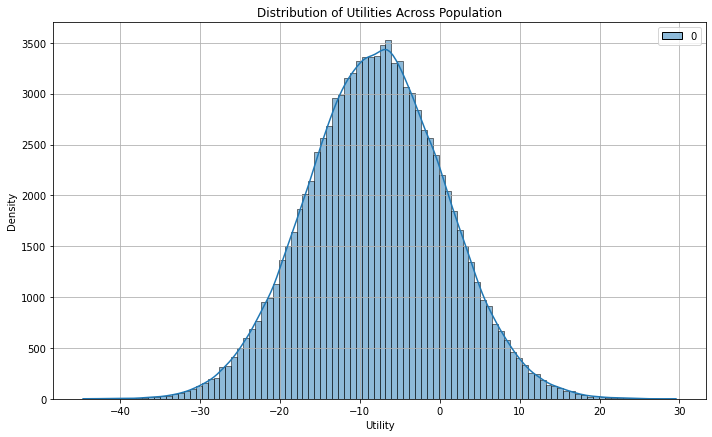

In [8]:
# visualize distribution of utilities across population given price
price = 5
sample_size = int(1e5)
cov = dgp.sample_individuals(sample_size=sample_size)
err_arr = dgp.sample_util_error(sample_size=sample_size)
utilities = dgp.calculate_utility(cov, price * np.ones((sample_size, 1)), err_arr)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))
sns.histplot(utilities, bins=100, kde=True, ax=ax)
ax.set_xlabel('Utility')
ax.set_ylabel('Density')
ax.set_title('Distribution of Utilities Across Population')
plt.grid()
plt.tight_layout()
plt.show()

# Estimators

In [9]:
# parameters
train_size = 1000
dgp_params = {
    'cov_dim': 1,
    'util_map_lb': -1, 'util_map_ub': 1, 
    'price_map_lb': -3, 'price_map_ub': -1, 
    'char_mean': 1, 'char_std': 1, 
    'price_lb': 0, 'price_ub': 50, 'price_diff': 0.05
}

# initialize the data generating process
dgp = PersonalizedPricingDGP(**dgp_params)

In [10]:
# generate training and testing data
cov_arr, price_arr, outcome_arr = dgp.generate_training_data(sample_size=train_size)

# plugin estimator
plugin_estmr = PricingPlugIn(cov_dim=dgp_params['cov_dim']).fit(covariates=cov_arr, prices=price_arr, outcomes=outcome_arr)
vc_estimr = PricingValueCorrection(cov_dim=dgp_params['cov_dim']).fit(covariates=cov_arr, prices=price_arr, outcomes=outcome_arr)
mnbvc_estmr = PricingMNBValueCorrection(cov_dim=dgp_params['cov_dim']).fit(covariates=cov_arr, prices=price_arr, outcomes=outcome_arr, q=0.86, max_j=20)

In [11]:
test_customer = dgp.sample_individuals(sample_size=1)

# clairvoyant
clairvoyant_opt_result = optimize_targeting(
    covariates=test_customer, params=dgp.true_util_params, 
    add_const=False, price_lb=dgp_params['price_lb'], price_ub=dgp_params['price_ub']
)
clairvoyant_price = clairvoyant_opt_result.x[0]
clairvoyant_targ_val = -clairvoyant_opt_result.fun

# plugin estimator 
plugin_price, plugin_targ_est = plugin_estmr.optimize(covariates=test_customer, price_lb=dgp_params['price_lb'], price_ub=dgp_params['price_ub'])
true_plugin_targ_val = obj_func(
    covariates=test_customer, price=plugin_price, params=dgp.true_util_params, add_const=False
)
vc_targ_est = vc_estimr.estimate_targeting_value(covariates=test_customer, price_lb=dgp_params['price_lb'], price_ub=dgp_params['price_ub'])
mnbvc_targ_est = mnbvc_estmr.estimate_targeting_value(covariates=test_customer, price_lb=dgp_params['price_lb'], price_ub=dgp_params['price_ub'])

print(f"Plugin price: {plugin_price:.4f}")
print(f"Clairvoyant price: {clairvoyant_price:.4f}")

print(f"\nPlugin Targeting estimate: {plugin_targ_est:.4f}")
print(f"Value Correction Targeting estimate: {vc_targ_est:.4f}")
print(f"MNB Value Correction Targeting estimate: {mnbvc_targ_est:.4f}")

print(f"\nActual value of plugin targeting: {true_plugin_targ_val:.4f}")
print(f"Winner's curse of plugin targeting: {plugin_targ_est - true_plugin_targ_val:.4f}", )
print(f"Winner's curse of value correction targeting: {vc_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's curse of MNB value correction targeting: {mnbvc_targ_est - true_plugin_targ_val:.4f}")

Plugin price: 0.4810
Clairvoyant price: 0.4112

Plugin Targeting estimate: 0.1955
Value Correction Targeting estimate: 0.1959
MNB Value Correction Targeting estimate: 0.1808

Actual value of plugin targeting: 0.1290
Winner's curse of plugin targeting: 0.0665
Winner's curse of value correction targeting: 0.0669
Winner's curse of MNB value correction targeting: 0.0518


# Experiments

In [33]:
# parameters
train_size = 1000
dgp_params = {
    'cov_dim': 1,
    'util_map_lb': -1, 'util_map_ub': 1, 
    'price_map_lb': -3, 'price_map_ub': -1, 
    'char_mean': 1, 'char_std': 1, 
    'price_lb': 0, 'price_ub': 50, 'price_diff': 0.05
}
estimators_dict = {
    'plugin': {
        'estimator': PricingPlugIn,
        'train_params': {},
        'targeting_params': {
            'price_lb': dgp_params['price_lb'],
            'price_ub': dgp_params['price_ub'], 
        }
    },
    'value_correction': {
        'estimator': PricingValueCorrection,
        'train_params': {},
        'targeting_params': {
            'price_lb': dgp_params['price_lb'],
            'price_ub': dgp_params['price_ub'], 
        }
    },
    'mnb_value_correction': {
        'estimator': PricingMNBValueCorrection,
        'train_params': {'q': 0.86, 'max_j': 20},
        'targeting_params': {
            'price_lb': dgp_params['price_lb'],
            'price_ub': dgp_params['price_ub'], 
        }
    }
}

In [34]:
dgp = PersonalizedPricingDGP(**dgp_params)

# generate training data 
cov_arr, price_arr, outcome_arr = dgp.generate_training_data(sample_size=train_size)

# run a single experiment
result_dict = single_pricing_experiment(
    dgp=dgp, 
    train_covariates=cov_arr, train_prices=price_arr, train_outcomes=outcome_arr,
    estimators_dict=estimators_dict, 
    customer_to_target=dgp.sample_individuals(sample_size=1)
)

result_dict

{'plugin': {'targ_est': 0.2443623765408917,
  'act_targ_val': 0.2397502115538897,
  'plugin_opt_price': 0.5073206689273596},
 'value_correction': {'targ_est': 0.23364995424731552},
 'mnb_value_correction': {'targ_est': 0.2527188078421529}}

In [35]:
results_df = grid_pricing_experiment(
    sample_sizes=[1000], 
    num_bootstraps=[500],
    dgp_params=dgp_params,
    estimators_dict=estimators_dict,
    num_training_samples=10, 
    num_test_customers_per_train_sample=10, 
    verbose=True, 
    save_dir=None
)

Fixed knobs: ['sample_size', 'num_bootstraps']
sample_size: [1000]
num_bootstraps: [500]
Time taken: 0:05:46.922501


In [36]:
results_df['act_plugin_val'].mean()

0.1247021249871665

In [37]:
for estimator in estimators_dict.keys():
    results_df[f'{estimator}_wc'] = results_df[f'{estimator}_est'] - results_df[f'act_plugin_val']

In [39]:
results_df[[col for col in results_df if col.endswith('wc')]].mean()

plugin_wc                  0.069573
value_correction_wc        0.065178
mnb_value_correction_wc   -0.001970
dtype: float64

In [41]:
results_df[[col for col in results_df if col.endswith('wc')]].std() / np.sqrt(1000)

plugin_wc                  0.006967
value_correction_wc        0.006858
mnb_value_correction_wc    0.007294
dtype: float64